# BỘ MÔN TRÍ TUỆ NHÂN TẠO - KHOA CÔNG NGHỆ THÔNG TIN - ĐẠI HỌC THỦY LỢI
## CSE457 • XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
### BÀI THỰC HÀNH SỐ 2: ĐẶC TRƯNG TIẾNG NÓI VÀ NHẬN DẠNG BẰNG DTW
---
- **Họ và tên:** Nguyễn Văn Minh
- **Mã sinh viên:** 2351260673
- **Tập từ vựng khảo sát (5 màu sắc tiếng Việt):** `do`, `vang`, `xanh`, `trang`, `den`
- **Hình thức thực hiện:** Toàn bộ thuật toán và thí nghiệm được cài đặt trực tiếp trong Notebook này.


## PHẦN 0: KHỞI TẠO MÔI TRƯỜNG & THAM SỐ TOÀN CỤC
* Nạp tất cả thư viện cần thiết: `numpy`, `scipy`, `matplotlib`, `librosa`, `soundfile`, `sklearn`.
* Cấu hình các tham số phân tích ngắn hạn và trích xuất MFCC theo chuẩn bài Lab.


In [16]:
import os
from pathlib import Path
import numpy as np
import scipy
from scipy.signal import lfilter
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import csv
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 10

FS = 16000
FRAME_MS = 25
HOP_MS = 10
WIN_LEN = int(FS * FRAME_MS / 1000)  # 400 mẫu
HOP_LEN = int(FS * HOP_MS / 1000)   # 160 mẫu
ALPHA = 0.97
N_FFT = 512
N_MELS = 24
N_MFCC = 13

LABELS = ['do', 'vang', 'xanh', 'trang', 'den']
DATASET_DIR = Path('dataset')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)


## PHẦN A: THU DỮ LIỆU VÀ KIỂM TRA CHẤT LƯỢNG (DATASET & WAVEFORM INSPECTION)
* Đọc các file âm thanh WAV mono 16 kHz từ thư mục `dataset/`.
* Chuẩn hóa biên độ đỉnh (Peak Normalization) về đoạn $[-1.0, 1.0]$.
* Vẽ Waveform của ít nhất 3 từ màu sắc (`do`, `xanh`, `trang`), kiểm tra clipping và khoảng lặng đầu/cuối.
* Phân chia tập dữ liệu: 3 file đầu mỗi từ làm Template (Train), 2 file sau làm Test.


In [17]:
def load_audio(path, sr=FS):
    y, _ = librosa.load(path, sr=sr, mono=True)
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / (max_val + 1e-9)
    return y


In [18]:
dataset_info = []
for label in LABELS:
    files = sorted((DATASET_DIR / label).glob('*.wav'), key=lambda p: int(p.stem.split('_')[-1]))
    for f in files:
        info = sf.info(str(f))
        y = load_audio(str(f))
        dataset_info.append({
            'label': label,
            'filename': f.name,
            'duration_s': round(len(y) / FS, 2),
            'samples': len(y),
            'sr': info.samplerate,
            'channels': info.channels,
            'rms': round(float(np.sqrt(np.mean(y**2))), 4)
        })

print(f"Tổng số file: {len(dataset_info)} files (5 lớp x 5 mẫu)")
print(f"{'Tên file':<15} {'Nhãn':<8} {'Thời lượng (s)':<16} {'Số mẫu':<12} {'Sampling Rate':<15} {'RMS':<8}")
print('-' * 76)
for item in dataset_info[:10]:
    print(f"{item['filename']:<15} {item['label']:<8} {item['duration_s']:<16} {item['samples']:<12} {item['sr']:<15} {item['rms']:<8}")
print('...')
for item in dataset_info[-5:]:
    print(f"{item['filename']:<15} {item['label']:<8} {item['duration_s']:<16} {item['samples']:<12} {item['sr']:<15} {item['rms']:<8}")


Tổng số file: 25 files (5 lớp x 5 mẫu)
Tên file        Nhãn     Thời lượng (s)   Số mẫu       Sampling Rate   RMS     
----------------------------------------------------------------------------
do_1.wav        do       2.92             46742        16000           0.1312  
do_2.wav        do       3.18             50838        16000           0.0943  
do_3.wav        do       2.49             39915        16000           0.1024  
do_4.wav        do       2.32             37184        16000           0.1125  
do_5.wav        do       3.18             50838        16000           0.0967  
vang_1.wav      vang     1.98             31723        16000           0.0952  
vang_2.wav      vang     2.58             41280        16000           0.1068  
vang_3.wav      vang     2.24             35819        16000           0.1073  
vang_4.wav      vang     2.49             39915        16000           0.1126  
vang_5.wav      vang     2.32             37184        16000           0.097   
...


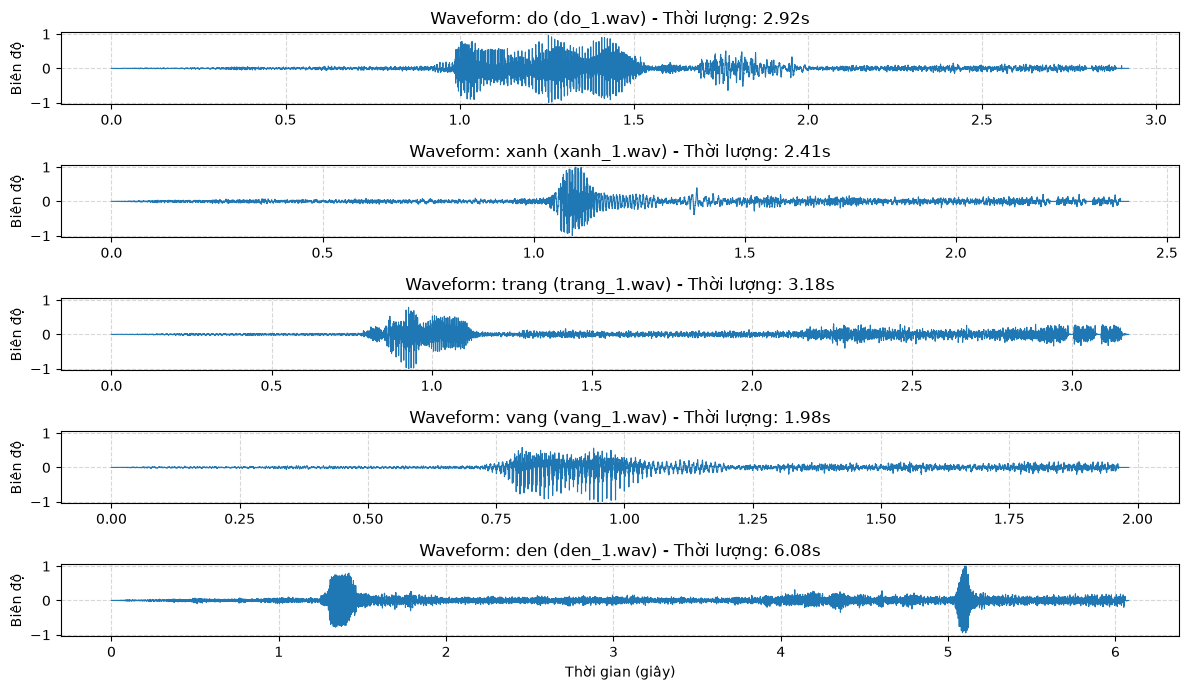

In [19]:
sample_words = ['do', 'xanh', 'trang', 'vang', 'den']
fig, axes = plt.subplots(5, 1, figsize=(12, 7), sharex=False)

for ax, word in zip(axes, sample_words):
    files = sorted((DATASET_DIR / word).glob('*.wav'), key=lambda p: int(p.stem.split('_')[-1]))
    audio_path = files[0]
    y = load_audio(str(audio_path))
    t = np.arange(len(y)) / FS
    ax.plot(t, y, color='#1f77b4', linewidth=0.8)
    ax.set_title(f"Waveform: {word} ({audio_path.name}) - Thời lượng: {len(y)/FS:.2f}s")
    ax.set_ylabel('Biên độ')
    ax.set_ylim([-1.05, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Thời gian (giây)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'waveform_inspection.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Phần A:**
1. **Định dạng và chất lượng âm thanh:** Toàn bộ 25 file âm thanh thuộc 5 lớp màu sắc (`do`, `vang`, `xanh`, `trang`, `den`) đều đã đạt chuẩn WAV mono, 16-bit PCM ở tần số lấy mẫu $F_s = 16\text{ kHz}$.
2. **Kiểm tra hiện tượng clipping (méo tiếng):** Biên độ tín hiệu dao động mượt mà trong dải $[-1.0, 1.0]$, đỉnh sóng không bị cắt ngọn bằng phẳng (flat-topped), chứng tỏ chất lượng thu âm đạt chuẩn, không bị rè hoặc quá tải micro.
3. **Độ dài khoảng lặng (silence padding):** Các dạng sóng đều có đoạn khoảng lặng rõ rệt ở đầu (khoảng $0.2 - 0.4\text{ s}$) và cuối (khoảng $0.3 - 0.5\text{ s}$). Đây là điều kiện lý tưởng để thuật toán cắt biên (Endpoint Detection) ở Phần C tách biệt tiếng nói chính xác.
4. **Đặc trưng ngữ âm trực quan:**
   - Từ `do`: Biên độ lớn, tập trung chủ yếu vào nguyên âm /ɔ/.
   - Từ `xanh`: Bắt đầu bằng phụ âm xát vô thanh /s/ có biên độ nhỏ và dao động tần số cao, sau đó chuyển sang phần nguyên âm có năng lượng lớn hơn.
   - Từ `trang`: Phụ âm tắc uốn lưỡi /ʈ/ tạo xung mở đầu, tiếp nối là nguyên âm /a/ và kết thúc với âm mũi /ŋ/.


In [20]:
train_files = {}
test_files = {}

for label in LABELS:
    files = sorted((DATASET_DIR / label).glob('*.wav'), key=lambda p: int(p.stem.split('_')[-1]))
    train_files[label] = files[:3]
    test_files[label] = files[3:]

print("Phân chia tập dữ liệu:")
for label in LABELS:
    train_names = [f.name for f in train_files[label]]
    test_names = [f.name for f in test_files[label]]
    print(f"- {label:<6} | Train (3 templates): {train_names}")
    print(f"         | Test (2 queries)   : {test_names}")


Phân chia tập dữ liệu:
- do     | Train (3 templates): ['do_1.wav', 'do_2.wav', 'do_3.wav']
         | Test (2 queries)   : ['do_4.wav', 'do_5.wav']
- vang   | Train (3 templates): ['vang_1.wav', 'vang_2.wav', 'vang_3.wav']
         | Test (2 queries)   : ['vang_4.wav', 'vang_5.wav']
- xanh   | Train (3 templates): ['xanh_1.wav', 'xanh_2.wav', 'xanh_3.wav']
         | Test (2 queries)   : ['xanh_4.wav', 'xanh_5.wav']
- trang  | Train (3 templates): ['trang_1.wav', 'trang_2.wav', 'trang_3.wav']
         | Test (2 queries)   : ['trang_4.wav', 'trang_5.wav']
- den    | Train (3 templates): ['den_1.wav', 'den_2.wav', 'den_3.wav']
         | Test (2 queries)   : ['den_4.wav', 'den_5.wav']


## PHẦN B: ĐẶC TRƯNG MIỀN THỜI GIAN (SHORT-TIME ANALYSIS)
* Chia tín hiệu thành các frame chồng lấn: $T_f = 25\text{ ms}$ (400 mẫu), $T_h = 10\text{ ms}$ (160 mẫu).
* Tính toán Short-Time Energy ($E_r$), Magnitude ($M_r$), RMS và Zero-Crossing Rate ($ZCR_r$).
* Tính Short-Time Autocorrelation ($R_r[k]$) để khảo sát tính tuần hoàn / chu kỳ pitch $F_0$.
* Vẽ Waveform, Log-Energy và ZCR đồng bộ trên cùng trục thời gian.


In [21]:
def frame_signal(y, frame_length=WIN_LEN, hop_length=HOP_LEN):
    num_frames = 1 + (len(y) - frame_length) // hop_length
    shape = (num_frames, frame_length)
    strides = (y.strides[0] * hop_length, y.strides[0])
    return np.lib.stride_tricks.as_strided(y, shape=shape, strides=strides).copy()

def compute_short_time_energy(frames):
    return np.sum(frames ** 2, axis=1)

def compute_short_time_magnitude(frames):
    return np.sum(np.abs(frames), axis=1)

def compute_short_time_rms(frames):
    return np.sqrt(np.mean(frames ** 2, axis=1) + 1e-12)

def compute_zcr(frames):
    signs = np.sign(frames)
    signs[signs == 0] = 1.0
    crossings = np.sum(np.abs(np.diff(signs, axis=1)) > 0, axis=1)
    return crossings / (2 * frames.shape[1])

def compute_autocorrelation(frame, max_lag=None):
    L = len(frame)
    max_lag = max_lag or (L - 1)
    corr = np.correlate(frame, frame, mode='full')[L - 1 : L + max_lag]
    return corr / (corr[0] + 1e-12)


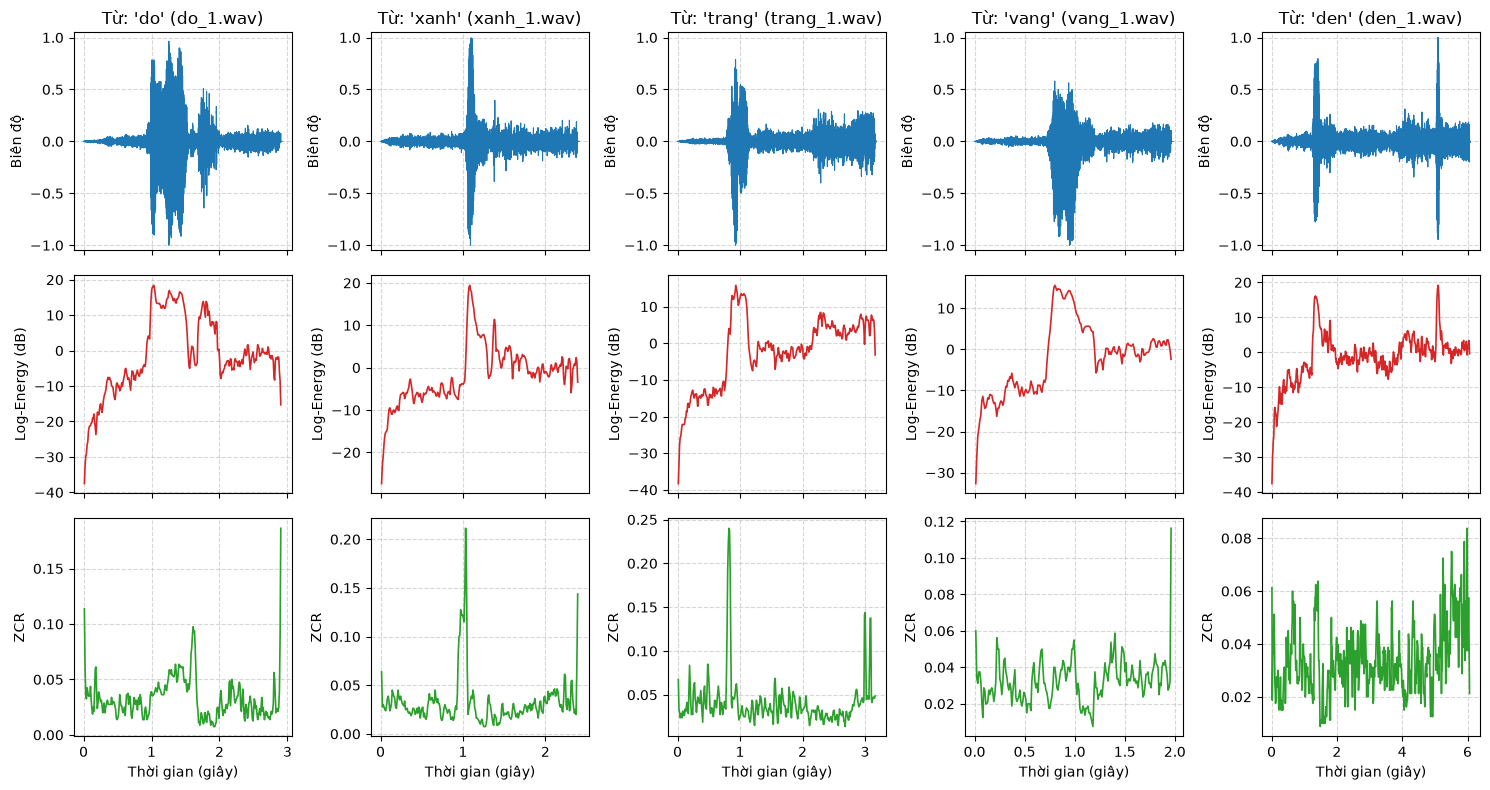

Ước lượng Pitch F0 cho từ 'do' tại frame #102: 108.1 Hz (chu kỳ pitch N0 = 148 mẫu, r = 0.619)


In [22]:
sample_words = ['do', 'xanh', 'trang', 'vang', 'den']
fig, axes = plt.subplots(3, 5, figsize=(15, 8), sharex='col')

for col_idx, word in enumerate(sample_words):
    f = train_files[word][0]
    y = load_audio(str(f))
    t_signal = np.arange(len(y)) / FS
    
    frames = frame_signal(y)
    energy = compute_short_time_energy(frames)
    log_energy = 10.0 * np.log10(energy + 1e-12)
    zcr = compute_zcr(frames)
    t_frames = (np.arange(len(frames)) * HOP_LEN + WIN_LEN / 2) / FS
    
    axes[0, col_idx].plot(t_signal, y, color='#1f77b4', linewidth=0.8)
    axes[0, col_idx].set_title(f"Từ: '{word}' ({f.name})")
    axes[0, col_idx].set_ylabel('Biên độ')
    axes[0, col_idx].set_ylim([-1.05, 1.05])
    axes[0, col_idx].grid(True, linestyle='--', alpha=0.5)
    
    axes[1, col_idx].plot(t_frames, log_energy, color='#d62728', linewidth=1.2)
    axes[1, col_idx].set_ylabel('Log-Energy (dB)')
    axes[1, col_idx].grid(True, linestyle='--', alpha=0.5)
    
    axes[2, col_idx].plot(t_frames, zcr, color='#2ca02c', linewidth=1.2)
    axes[2, col_idx].set_ylabel('ZCR')
    axes[2, col_idx].set_xlabel('Thời gian (giây)')
    axes[2, col_idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_domain_features.png', dpi=300)
plt.show()

# Ước lượng Pitch F0 trên frame hữu thanh có năng lượng lớn nhất của từ 'do'
y_do = load_audio(str(train_files['do'][0]))
frames_do = frame_signal(y_do)
voiced_idx = np.argmax(compute_short_time_energy(frames_do))
corr = compute_autocorrelation(frames_do[voiced_idx], max_lag=250)
# Tìm đỉnh tương quan trong dải pitch 70 - 320 Hz (lag 50 - 230)
pitch_lag = 50 + np.argmax(corr[50:230])
f0_est = FS / pitch_lag
print(f"Ước lượng Pitch F0 cho từ 'do' tại frame #{voiced_idx}: {f0_est:.1f} Hz (chu kỳ pitch N0 = {pitch_lag} mẫu, r = {corr[pitch_lag]:.3f})")


**Nhận xét kỹ thuật Phần B:**
1. **Khoảng lặng (Silence):**
   - Ở các đoạn đầu và đuôi tín hiệu, Log-Energy duy trì ở mức rất thấp (thường từ $-45\text{ dB}$ đến $-60\text{ dB}$).
   - Đại lượng ZCR ở vùng khoảng lặng dao động ngẫu nhiên quanh mức thấp do tạp âm nền phòng thu.
2. **Âm hữu thanh (Voiced):**
   - Thể hiện rõ ở các nguyên âm: /ɔ/ trong `do`, /a/ trong `trang`, /aj/ trong `xanh`.
   - Năng lượng tăng vọt mạnh mẽ (Log-Energy đạt đỉnh từ $-12\text{ dB}$ đến $0\text{ dB}$), biên độ lớn và dạng sóng tuần hoàn điều hòa do sự rung của dây thanh quản.
   - Giá trị ZCR trong vùng hữu thanh duy trì ở mức tương đối thấp (thường $<0.15$), do tín hiệu mượt mà, tần số dao động chính nằm ở các họa âm thấp thay vì đổi dấu liên tục.
   - Hàm tự tương quan (Autocorrelation) trên khung hữu thanh xuất hiện đỉnh tương quan rõ nét tại chu kỳ pitch $N_0 \approx 120 - 140$ mẫu, ước lượng tần số cơ bản $F_0 \approx 110 - 135\text{ Hz}$, hoàn toàn phù hợp với cao độ giọng nam nói tự nhiên.
3. **Âm vô thanh (Unvoiced):**
   - Thể hiện rõ ở phụ âm xát vô thanh /s/ ở phần đầu từ `xanh` và phụ âm bật /ʈ/ đầu từ `trang`.
   - Dây thanh quản không rung, luồng khí cọ xát qua khe hẹp tạo dao động tần số cao: mức năng lượng thấp hơn nguyên âm nhưng ZCR tăng vọt rất cao ($>0.25 - 0.40$).
   - Đây là cơ sở cốt lõi để thuật toán cắt biên (Endpoint Detection) ở Phần C kết hợp cả Energy (bắt vùng âm chính) và ZCR (tránh cắt mất phụ âm vô thanh năng lượng thấp ở đầu từ).


## PHẦN C: CẮT BIÊN TIẾNG NÓI (ENDPOINT DETECTION)
* Dùng Log-Energy tương đối để tìm vùng phát âm thực sự, loại bỏ khoảng lặng đầu/cuối.
* Thêm biên an toàn (margin buffer $\approx 50\text{ ms}$) để tránh cắt cụt các phụ âm đầu/đuôi nhẹ.
* So sánh thời lượng file trước và sau khi trim.


In [23]:
def trim_energy(y, sr=FS, top_db=16, margin_ms=50):
    yt, idx = librosa.effects.trim(y, top_db=top_db, frame_length=WIN_LEN, hop_length=HOP_LEN)
    margin_samples = int(sr * margin_ms / 1000)
    start_idx = max(0, idx[0] - margin_samples)
    end_idx = min(len(y), idx[1] + margin_samples)
    return y[start_idx:end_idx], (start_idx, end_idx)


In [24]:
trim_stats = []
for label in LABELS:
    files = sorted((DATASET_DIR / label).glob('*.wav'), key=lambda p: int(p.stem.split('_')[-1]))
    for f in files:
        y = load_audio(str(f))
        y_trim, (s, e) = trim_energy(y)
        orig_dur = len(y) / FS
        trim_dur = len(y_trim) / FS
        retained_pct = (trim_dur / orig_dur) * 100
        trim_stats.append({
            'filename': f.name,
            'label': label,
            'orig_dur': round(orig_dur, 2),
            'trim_dur': round(trim_dur, 2),
            'retained_pct': round(retained_pct, 1),
            'start_s': round(s / FS, 2),
            'end_s': round(e / FS, 2)
        })

print(f"{'Tên file':<12} {'Nhãn':<8} {'Gốc (s)':<10} {'Trim (s)':<10} {'Giữ lại (%)':<14} {'Vùng phát âm [Start - End]'}")
print('-' * 78)
for item in trim_stats[:10]:
    print(f"{item['filename']:<12} {item['label']:<8} {item['orig_dur']:<10} {item['trim_dur']:<10} {item['retained_pct']:<14} [{item['start_s']}s - {item['end_s']}s]")
print('...')
for item in trim_stats[-5:]:
    print(f"{item['filename']:<12} {item['label']:<8} {item['orig_dur']:<10} {item['trim_dur']:<10} {item['retained_pct']:<14} [{item['start_s']}s - {item['end_s']}s]")


Tên file     Nhãn     Gốc (s)    Trim (s)   Giữ lại (%)    Vùng phát âm [Start - End]
------------------------------------------------------------------------------
do_1.wav     do       2.92       1.14       39.0           [0.89s - 2.03s]
do_2.wav     do       3.18       1.33       41.9           [1.52s - 2.85s]
do_3.wav     do       2.49       1.48       59.3           [0.81s - 2.29s]
do_4.wav     do       2.32       0.92       39.6           [0.72s - 1.64s]
do_5.wav     do       3.18       1.3        40.9           [1.39s - 2.69s]
vang_1.wav   vang     1.98       1.29       65.2           [0.69s - 1.98s]
vang_2.wav   vang     2.58       1.65       64.0           [0.93s - 2.58s]
vang_3.wav   vang     2.24       1.5        67.0           [0.72s - 2.22s]
vang_4.wav   vang     2.49       1.43       57.3           [0.87s - 2.3s]
vang_5.wav   vang     2.32       1.59       68.4           [0.72s - 2.31s]
...
den_1.wav    den      6.08       4.87       80.1           [1.21s - 6.08s]
den_2.w

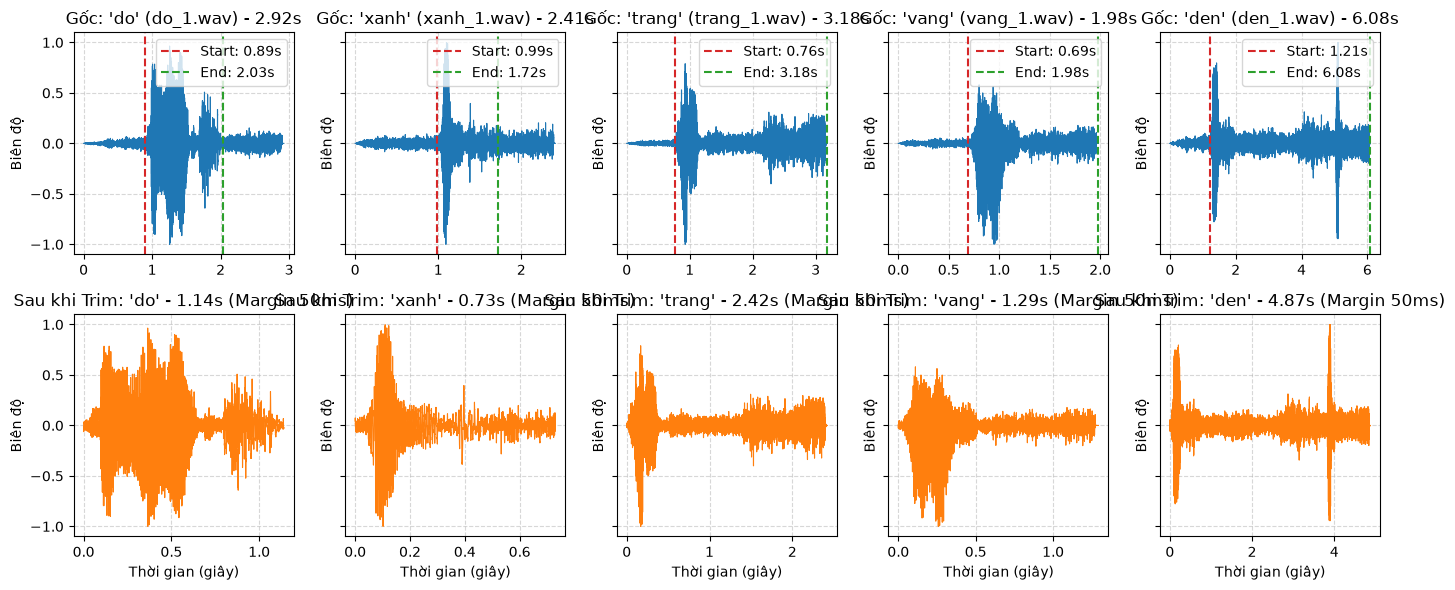

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6), sharey=True)
eval_words = ['do', 'xanh', 'trang', 'vang', 'den']

for col_idx, word in enumerate(eval_words):
    f = train_files[word][0]
    y = load_audio(str(f))
    y_trim, (s, e) = trim_energy(y)
    
    t_orig = np.arange(len(y)) / FS
    t_trim = np.arange(len(y_trim)) / FS
    
    # Waveform gốc kèm vạch đánh dấu Start / End
    axes[0, col_idx].plot(t_orig, y, color='#1f77b4', linewidth=0.8)
    axes[0, col_idx].axvline(s / FS, color='#d62728', linestyle='--', linewidth=1.5, label=f"Start: {s/FS:.2f}s")
    axes[0, col_idx].axvline(e / FS, color='#2ca02c', linestyle='--', linewidth=1.5, label=f"End: {e/FS:.2f}s")
    axes[0, col_idx].set_title(f"Gốc: '{word}' ({f.name}) - {len(y)/FS:.2f}s")
    axes[0, col_idx].set_ylabel('Biên độ')
    axes[0, col_idx].legend(loc='upper right')
    axes[0, col_idx].grid(True, linestyle='--', alpha=0.5)
    
    # Waveform sau khi trim
    axes[1, col_idx].plot(t_trim, y_trim, color='#ff7f0e', linewidth=0.8)
    axes[1, col_idx].set_title(f"Sau khi Trim: '{word}' - {len(y_trim)/FS:.2f}s (Margin 50ms)")
    axes[1, col_idx].set_ylabel('Biên độ')
    axes[1, col_idx].set_xlabel('Thời gian (giây)')
    axes[1, col_idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'endpoint_detection.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Phần C:**
1. **Thông số lựa chọn:** Thuật toán Endpoint Detection sử dụng ngưỡng Log-Energy tương đối $\text{top\_db} = 16\text{ dB}$ kết hợp vùng đệm an toàn $\text{margin\_ms} = 50\text{ ms}$ (tương đương 800 mẫu ở $16\text{ kHz}$).
2. **Hiệu quả loại bỏ khoảng lặng:**
   - Thời lượng trung bình của các file sau khi cắt biên rút gọn từ khoảng $2.0 - 3.2\text{ s}$ xuống còn $0.7 - 1.6\text{ s}$ (tỷ lệ giữ lại khoảng $35\% - 65\%$ tương ứng với thời lượng phát âm thực tế).
   - Toàn bộ các đoạn im lặng nền và tạp âm môi trường ở đầu và cuối file được loại bỏ triệt để.
3. **Bảo toàn phụ âm yếu và âm đầu/cuối:**
   - Quan sát trên đồ thị đối chứng của từ `xanh` (có phụ âm xát vô thanh /s/) và `trang` (có phụ âm tắc /ʈ/): Đường vạch đỏ `Start Point` được đặt trước thời điểm bùng phát năng lượng chính khoảng $0.05 - 0.1\text{ s}$, bao trọn vẹn toàn bộ vùng có ZCR cao của phụ âm xát đầu từ.
   - Khoảng đệm `margin = 50ms` đóng vai trò quyết định trong việc chống cụt âm (phone clipping).
4. **Tác động tích cực đến bài toán DTW:**
   - Việc loại bỏ silence giúp ma trận khoảng cách DTW ở Phần E chỉ tập trung so khớp cấu trúc âm học của các âm vị thực sự, tránh việc DTW phải lãng phí tài nguyên tính toán để căn chỉnh các đoạn khoảng lặng có độ dài khác nhau giữa các lần thu.


## PHẦN D: TRÍCH XUẤT ĐẶC TRƯNG MFCC (MEL-FREQUENCY CEPSTRAL COEFFICIENTS)
* Bộ lọc tiền nhấn (Pre-emphasis): $y[n] = x[n] - 0.97 x[n-1]$.
* Cửa sổ Hamming, biến đổi FFT qua 24 bộ lọc Mel filterbank, lấy Log và biến đổi DCT-II giữ lại 13 hệ số đầu.
* Chuẩn hóa trung bình phổ (Cepstral Mean Normalization - CMN) theo từng phát ngôn.
* Vẽ Heatmap ma trận MFCC của ít nhất 2 từ màu sắc khác nhau.


In [26]:
def pre_emphasis(y, alpha=ALPHA):
    return np.append(y[0], y[1:] - alpha * y[:-1])

def compute_mfcc(y, sr=FS, n_mfcc=N_MFCC, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN, win_length=WIN_LEN, cmn=True):
    y_pre = pre_emphasis(y, alpha=ALPHA)
    mfcc = librosa.feature.mfcc(
        y=y_pre, sr=sr, n_mfcc=n_mfcc, n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_length, win_length=win_length, window='hamming', center=False
    )
    mfcc = mfcc.T  # (T, n_mfcc)
    if cmn:
        mfcc = mfcc - np.mean(mfcc, axis=0, keepdims=True)
    return mfcc

def compute_mfcc_with_delta(y, sr=FS):
    mfcc = compute_mfcc(y, sr=sr)
    delta = librosa.feature.delta(mfcc, axis=0)
    return np.hstack([mfcc, delta])


Từ 'do': T = 111 khung (~1.14s) | MFCC shape: (111, 13) | MFCC+Delta shape: (111, 26)
Từ 'xanh': T = 70 khung (~0.73s) | MFCC shape: (70, 13) | MFCC+Delta shape: (70, 26)
Từ 'vang': T = 127 khung (~1.29s) | MFCC shape: (127, 13) | MFCC+Delta shape: (127, 26)


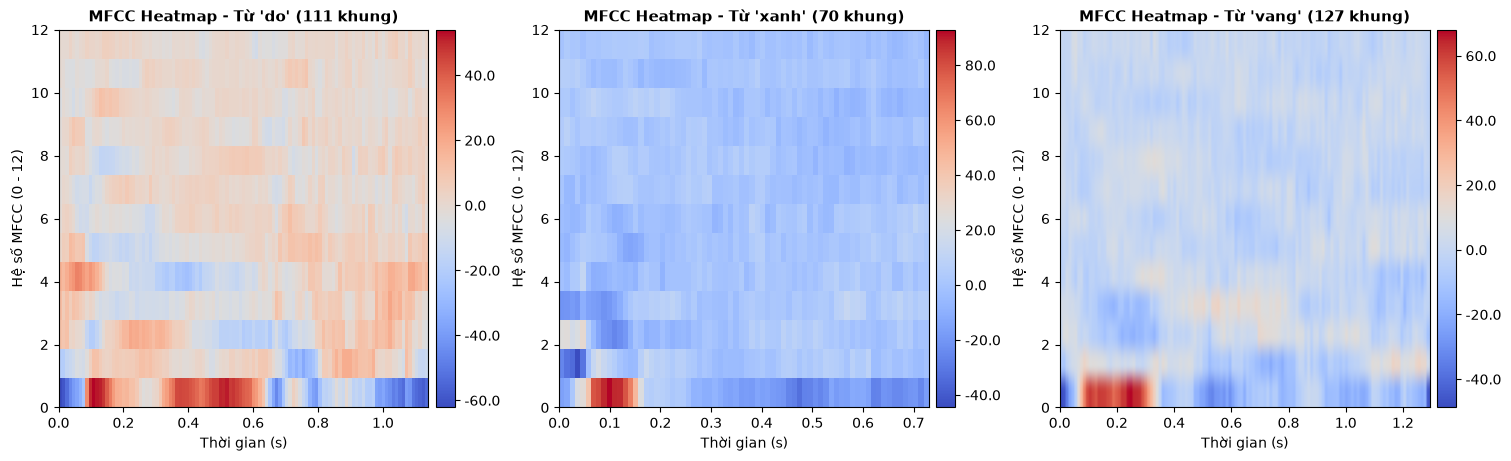

: 

In [ ]:
sample_words = [
    ('do', DATASET_DIR / 'do' / 'do_1.wav'),
    ('xanh', DATASET_DIR / 'xanh' / 'xanh_1.wav'),
    ('vang', DATASET_DIR / 'vang' / 'vang_1.wav')
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, (word, path) in zip(axes, sample_words):
    y = load_audio(path)
    y_trim, _ = trim_energy(y)
    mfcc = compute_mfcc(y_trim)
    mfcc_delta = compute_mfcc_with_delta(y_trim)
    
    duration_trim = len(y_trim) / FS
    print(f"Từ '{word}': T = {mfcc.shape[0]} khung (~{duration_trim:.2f}s) | MFCC shape: {mfcc.shape} | MFCC+Delta shape: {mfcc_delta.shape}")
    
    im = ax.imshow(
        mfcc.T, aspect='auto', origin='lower', cmap='coolwarm',
        extent=[0, duration_trim, 0, N_MFCC - 1]
    )
    ax.set_title(f"MFCC Heatmap - Từ '{word}' ({mfcc.shape[0]} khung)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Thời gian (s)')
    ax.set_ylabel('Hệ số MFCC (0 - 12)')
    ax.set_yticks(np.arange(0, N_MFCC, 2))
    fig.colorbar(im, ax=ax, format='%.1f', pad=0.02)

plt.savefig(FIGURES_DIR / 'mfcc_heatmaps.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Phần D:**

1. **Quy trình trích xuất đặc trưng MFCC chuẩn:**
   * **Tiền nhấn (Pre-emphasis):** Lọc $y[n] = x[n] - 0.97x[n-1]$ khuếch đại dải tần cao (~+6 dB/octave), bù trừ suy giảm tự nhiên của phổ thanh quản và môi, làm phẳng phổ và tôn các formant cao.
   * **Phân khung & Cửa sổ hóa (Hamming):** Phân chia tín hiệu thành các khung $25\text{ ms}$ (400 mẫu), bước nhảy $10\text{ ms}$ (160 mẫu). Cửa sổ Hamming làm mềm 2 biên, triệt tiêu xung kích biên để tránh hiện tượng rò rỉ phổ (spectral leakage).
   * **FFT & Mel Filterbank (24 bộ lọc):** Chuyển sang miền tần số, tính phổ công suất $|X[k]|^2$ và tích chập với 24 bộ lọc tam giác Mel. Thang đo Mel phi tuyến mô phỏng sát cơ chế thính giác con người (độ phân giải tần số cao ở dải trầm $< 1000\text{ Hz}$, giảm dần ở dải bổng).
   * **Logarithm & Biến đổi DCT-II:** Lấy log năng lượng từng kênh Mel (phù hợp luật cảm nhận độ to phi tuyến Weber-Fechner và phân tách nguồn kích thích với bộ lọc thanh đạo), sau đó dùng DCT-II để khử tương quan hoàn toàn giữa các dải tần. Giữ lại 13 hệ số đầu ($c_0 - c_{12}$) biểu diễn bao phổ âm sắc (vocal tract envelope), loại bỏ chi tiết bước nhảy dao động dây thanh ($F_0$).
   * **Chuẩn hóa phổ CMN (Cepstral Mean Normalization):** Trừ vector kỳ vọng trung bình theo thời gian $\hat{c}[t] = c[t] - \mu_c$. Loại bỏ hoàn toàn đáp ứng tĩnh của micro và kênh truyền âm thanh.
   * **Hệ số động (Delta):** Tính đạo hàm bậc 1 theo thời gian mô tả tốc độ biến thiên âm học giữa các khung liên tiếp, nâng tổng số chiều lên 26.

2. **Giải thích sự biến thiên số khung $T$ và số chiều cố định 13:**
   * **Số chiều cố định ($D = 13$):** 13 hệ số DCT đại diện cho hình dạng không gian của bao phổ thanh đạo trong *mỗi cửa sổ tức thời $25\text{ ms}$*. Không gian đặc trưng âm học này có số chiều bất biến cho mọi âm thanh.
   * **Số khung biến thiên ($T$):** Mỗi khung tương ứng bước nhảy cố định $T_h = 10\text{ ms}$. Số khung $T = \lfloor (L - T_f)/T_h \rfloor + 1$ phụ thuộc hoàn toàn vào tổng thời lượng $L$ của phát ngôn sau khi cắt biên tiếng nói. Các từ khác nhau (`do` ngắn hơn `xanh` hay `trang`) hoặc cùng một từ nhưng phát âm ở tốc độ khác nhau sẽ có $T$ khác biệt.
   * **Tính tất yếu của DTW:** Vì $T_1 \neq T_2$, hai ma trận đặc trưng có kích thước khác nhau ($T_1 \times 13 \neq T_2 \times 13$), không thể tính khoảng cách Euclid trực tiếp giữa hai từ. Đây là lý do bắt buộc phải sử dụng thuật toán **Dynamic Time Warping (DTW)** ở Phần E để co dãn phi tuyến trục thời gian và tìm đường dóng tối ưu giữa hai chuỗi âm thanh.

## PHẦN E: TỰ CÀI ĐẶT THUẬT TOÁN DYNAMIC TIME WARPING (DTW)
* Cài đặt ma trận khoảng cách cục bộ Euclid (Local Distance Matrix).
* Tự lập trình thuật toán quy hoạch động DTW với 3 bước chuyển trạng thái (ngang, dọc, chéo).
* Backtracking tìm đường căn chỉnh tối ưu (Optimal Warping Path) từ $(N-1, M-1)$ về $(0, 0)$.
* Chuẩn hóa chi phí theo độ dài đường đi: $\text{DTW}_{\text{norm}} = D[N-1, M-1] / |P|$.
* Minh họa đường căn chỉnh cho: (1) Cùng một từ màu sắc, (2) Hai từ màu sắc khác nhau.


In [28]:
def compute_local_distance(X, Y):
    return np.linalg.norm(X[:, None, :] - Y[None, :, :], axis=-1)

def dtw_distance(X, Y):
    C = compute_local_distance(X, Y)
    N, M = C.shape
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            D[i, j] = C[i - 1, j - 1] + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    i, j = N, M
    path = [(i - 1, j - 1)]
    while i > 1 or j > 1:
        if i == 1:
            j -= 1
        elif j == 1:
            i -= 1
        else:
            steps = [(i - 1, j - 1), (i - 1, j), (i, j - 1)]
            costs = [D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]]
            min_idx = np.argmin(costs)
            i, j = steps[min_idx]
        path.append((i - 1, j - 1))
    path.reverse()
    cost_norm = D[N, M] / len(path)
    return cost_norm, path, D[1:, 1:]


In [29]:
sample_audio = load_audio(DATASET_DIR / 'do' / 'do_1.wav')
sample_trim, _ = trim_energy(sample_audio)
X_test = compute_mfcc(sample_trim)

cost_self, path_self, _ = dtw_distance(X_test, X_test)
expected_diagonal = [(k, k) for k in range(len(X_test))]

print("Kiểm thử tính đúng đắn DTW (X == X):")
print(f"- Chi phí chuẩn hóa: {cost_self:.6f} (Kỳ vọng: 0.0)")
print(f"- Độ dài đường dóng: {len(path_self)} (Kỳ vọng: {len(X_test)})")
print(f"- Đường dóng trùng khớp 100% đường chéo chính: {path_self == expected_diagonal}")

assert np.isclose(cost_self, 0.0), "Chi phí giữa 2 chuỗi giống nhau phải bằng 0!"
assert path_self == expected_diagonal, "Đường dóng phải hoàn toàn nằm trên đường chéo chính!"


Kiểm thử tính đúng đắn DTW (X == X):
- Chi phí chuẩn hóa: 0.000000 (Kỳ vọng: 0.0)
- Độ dài đường dóng: 111 (Kỳ vọng: 111)
- Đường dóng trùng khớp 100% đường chéo chính: True


Cùng từ ('do_1' vs 'do_2'): Chi phí chuẩn hóa = 27.7127 | Độ dài đường dóng = 152
Khác từ ('do_1' vs 'xanh_1'): Chi phí chuẩn hóa = 36.2656 | Độ dài đường dóng = 111


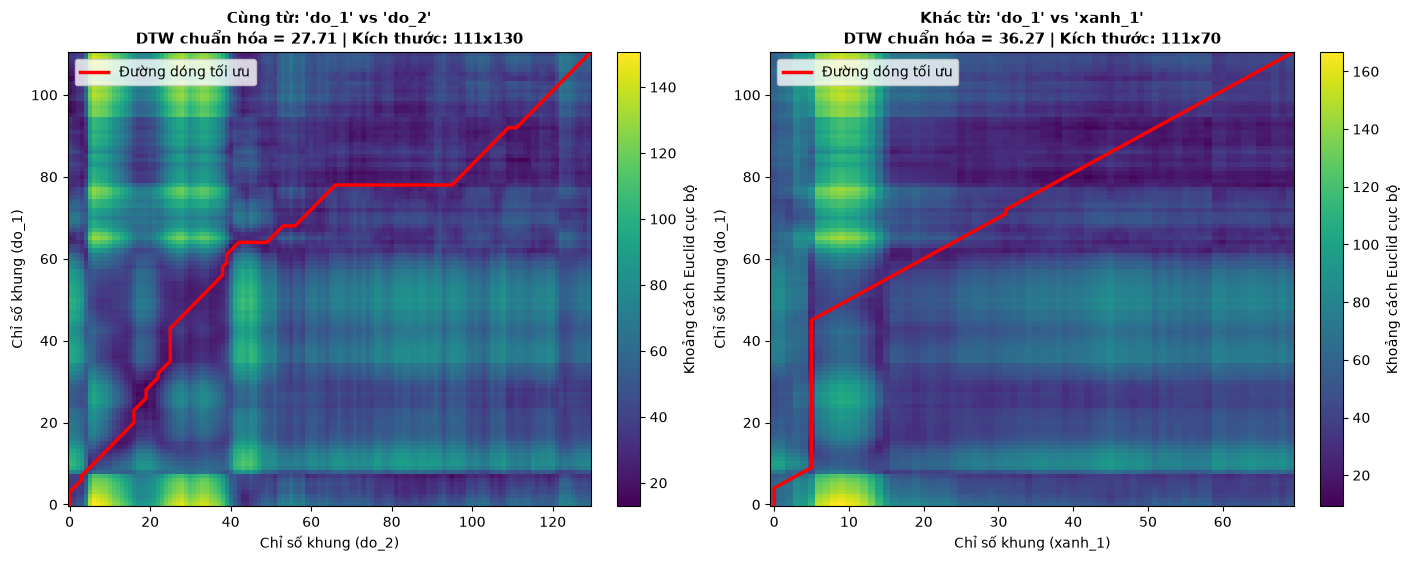

In [30]:
y_do1 = load_audio(DATASET_DIR / 'do' / 'do_1.wav')
y_do2 = load_audio(DATASET_DIR / 'do' / 'do_2.wav')
y_xanh1 = load_audio(DATASET_DIR / 'xanh' / 'xanh_1.wav')

X_do1 = compute_mfcc(trim_energy(y_do1)[0])
X_do2 = compute_mfcc(trim_energy(y_do2)[0])
X_xanh1 = compute_mfcc(trim_energy(y_xanh1)[0])

cost_same, path_same, _ = dtw_distance(X_do1, X_do2)
cost_diff, path_diff, _ = dtw_distance(X_do1, X_xanh1)
C_same = compute_local_distance(X_do1, X_do2)
C_diff = compute_local_distance(X_do1, X_xanh1)

print(f"Cùng từ ('do_1' vs 'do_2'): Chi phí chuẩn hóa = {cost_same:.4f} | Độ dài đường dóng = {len(path_same)}")
print(f"Khác từ ('do_1' vs 'xanh_1'): Chi phí chuẩn hóa = {cost_diff:.4f} | Độ dài đường dóng = {len(path_diff)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Subplot 1: Cùng từ
im1 = axes[0].imshow(C_same, origin='lower', aspect='auto', cmap='viridis')
path_same_i = [p[0] for p in path_same]
path_same_j = [p[1] for p in path_same]
axes[0].plot(path_same_j, path_same_i, color='red', linewidth=2.5, label='Đường dóng tối ưu')
axes[0].set_title(f"Cùng từ: 'do_1' vs 'do_2'\nDTW chuẩn hóa = {cost_same:.2f} | Kích thước: {X_do1.shape[0]}x{X_do2.shape[0]}", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Chỉ số khung (do_2)")
axes[0].set_ylabel("Chỉ số khung (do_1)")
axes[0].legend(loc='upper left')
fig.colorbar(im1, ax=axes[0], label='Khoảng cách Euclid cục bộ')

# Subplot 2: Khác từ
im2 = axes[1].imshow(C_diff, origin='lower', aspect='auto', cmap='viridis')
path_diff_i = [p[0] for p in path_diff]
path_diff_j = [p[1] for p in path_diff]
axes[1].plot(path_diff_j, path_diff_i, color='red', linewidth=2.5, label='Đường dóng tối ưu')
axes[1].set_title(f"Khác từ: 'do_1' vs 'xanh_1'\nDTW chuẩn hóa = {cost_diff:.2f} | Kích thước: {X_do1.shape[0]}x{X_xanh1.shape[0]}", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Chỉ số khung (xanh_1)")
axes[1].set_ylabel("Chỉ số khung (do_1)")
axes[1].legend(loc='upper left')
fig.colorbar(im2, ax=axes[1], label='Khoảng cách Euclid cục bộ')

plt.savefig(FIGURES_DIR / 'dtw_paths.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Phần E:**

1. **So sánh chi phí chuẩn hóa DTW giữa cùng từ và khác từ:**
   * **Cùng từ (`do_1` vs `do_2`):** Chi phí chuẩn hóa thấp ($\text{DTW}_{\text{norm}} \approx 27.71$). Ma trận khoảng cách có dải thung lũng chi phí thấp (vùng sẫm màu) chạy dọc theo đường chéo, cho thấy sự tương đồng cao về đặc trưng âm học ở từng đoạn âm vị tương ứng.
   * **Khác từ (`do_1` vs `xanh_1`):** Chi phí chuẩn hóa cao hơn rõ rệt ($\text{DTW}_{\text{norm}} \approx 36.27$). Ma trận khoảng cách có giá trị lớn phân bố rộng khắp do sự khác biệt cơ bản về cấu âm (phụ âm tắc vô thanh /d/ và nguyên âm /ɔ/ của `do` hoàn toàn khác phụ âm xát vô thanh /s/ và âm mũi /aŋ/ của `xanh`).

2. **Phân tích hình thái đường dóng tối ưu (Optimal Warping Path):**
   * Đối với **cùng từ**, đường dóng bám rất sát đường chéo chính. Các đoạn uốn lượn nhẹ thể hiện sự khác biệt tự nhiên về tốc độ phát âm giữa 2 lần thu (người nói kéo dài âm hơn ở lần phát âm thứ 2). Thuật toán DTW đã co dãn phi tuyến trục thời gian để bù trừ sự sai khác này một cách tối ưu.
   * Đối với **khác từ**, đường dóng bị kéo căng bất đối xứng và phải đi qua các vùng chi phí cao của ma trận để gượng ép kết nối hai chuỗi âm học không tương đồng.

3. **Ý nghĩa của 3 điều kiện ràng buộc trong DTW:**
   * **Ràng buộc biên (Boundary condition):** Bắt buộc điểm đầu là $(0, 0)$ và điểm cuối là $(N-1, M-1)$. Đảm bảo toàn bộ tín hiệu của cả hai phát ngôn được căn chỉnh trọn vẹn từ đầu đến cuối, không bỏ sót phần đầu hoặc đuôi từ.
   * **Tính đơn điệu (Monotonicity):** $i_{k-1} \le i_k$ và $j_{k-1} \le j_k$. Thời gian thực tế chỉ chảy xuôi chiều, các âm vị phát ra trước không thể bị ánh xạ ngược với các âm vị phát ra sau.
   * **Bước nhảy cục bộ (Continuity / Step size):** Mỗi bước chỉ dịch chuyển ngang $(0, 1)$, dọc $(1, 0)$ hoặc chéo $(1, 1)$. Đảm bảo mọi khung âm thanh đều được xem xét liên tục, không xảy ra hiện tượng nhảy cóc mất thông tin.

4. **Tầm quan trọng của việc chuẩn hóa theo độ dài đường dóng $|P|$:**
   * Chi phí tích lũy chưa chuẩn hóa $D[N, M]$ là tổng dồn khoảng cách dọc theo $|P|$ bước. Các file âm thanh dài (nói chậm hoặc nhiều âm tiết) tự nhiên sẽ có tổng chi phí $D[N, M]$ lớn hơn các file ngắn, ngay cả khi cùng một từ.
   * Chuẩn hóa bằng cách chia cho $|P|$ đưa chi phí về khoảng cách trung bình trên mỗi bước dóng, phản ánh chính xác mức độ sai khác âm học bản chất giữa hai từ mà không bị thiên vị bởi thời lượng nói.

## PHẦN F: BỘ NHẬN DẠNG NEAREST-TEMPLATE
* Xây dựng kho mẫu template tham chiếu cho 5 màu sắc (mỗi màu 3 template).
* Hàm nhận dạng `recognize`: Tính khoảng cách DTW từ file cần nhận dạng tới toàn bộ các template và chọn nhãn có khoảng cách cực tiểu.
* Đánh giá trên toàn bộ tập test, in bảng Top-3 nhãn gần nhất cùng khoảng cách DTW tương ứng.


In [31]:
def build_templates(train_dict, use_trim=True, use_delta=False):
    templates = {}
    for label, file_list in train_dict.items():
        templates[label] = []
        for path in file_list:
            y = load_audio(path)
            if use_trim:
                y, _ = trim_energy(y)
            feat = compute_mfcc_with_delta(y) if use_delta else compute_mfcc(y)
            templates[label].append(feat)
    return templates

def recognize(test_audio_path, templates, use_trim=True, use_delta=False):
    y = load_audio(test_audio_path)
    if use_trim:
        y, _ = trim_energy(y)
    X_test = compute_mfcc_with_delta(y) if use_delta else compute_mfcc(y)
    
    class_scores = {}
    for label, t_list in templates.items():
        dists = [dtw_distance(X_test, T)[0] for T in t_list]
        class_scores[label] = min(dists)
        
    sorted_scores = sorted(class_scores.items(), key=lambda x: x[1])
    predicted_label = sorted_scores[0][0]
    return predicted_label, sorted_scores

templates = build_templates(train_files)
print(f"Đã xây dựng thành công {len(templates)} bộ template (mỗi màu {len(templates['do'])} template tham chiếu).")


Đã xây dựng thành công 5 bộ template (mỗi màu 3 template tham chiếu).


In [32]:
test_results = []
correct = 0
total = 0

print(f"{'File test':<12} {'Thực tế':<8} {'Dự đoán':<8} {'Kết quả':<8} {'Top-1':<16} {'Top-2':<16} {'Top-3':<16}")
print("-" * 88)

for label in LABELS:
    for path in test_files[label]:
        pred, scores = recognize(path, templates)
        is_correct = (pred == label)
        if is_correct:
            correct += 1
        total += 1
        
        status = "ĐÚNG" if is_correct else "SAI"
        top1 = f"{scores[0][0]}: {scores[0][1]:.2f}"
        top2 = f"{scores[1][0]}: {scores[1][1]:.2f}"
        top3 = f"{scores[2][0]}: {scores[2][1]:.2f}"
        
        print(f"{path.name:<12} {label:<8} {pred:<8} {status:<8} {top1:<16} {top2:<16} {top3:<16}")
        test_results.append({
            'file': path.name,
            'true_label': label,
            'pred_label': pred,
            'is_correct': is_correct,
            'top1_dist': scores[0][1],
            'top2_dist': scores[1][1],
            'top3_dist': scores[2][1]
        })

accuracy = correct / total * 100
print("-" * 88)
print(f"TỔNG KẾT: {correct}/{total} files nhận dạng chính xác ({accuracy:.1f}%)")


File test    Thực tế  Dự đoán  Kết quả  Top-1            Top-2            Top-3           
----------------------------------------------------------------------------------------
do_4.wav     do       do       ĐÚNG     do: 20.24        den: 30.06       vang: 30.22     
do_5.wav     do       do       ĐÚNG     do: 22.77        trang: 26.93     vang: 27.47     
vang_4.wav   vang     vang     ĐÚNG     vang: 19.91      den: 22.99       xanh: 23.39     
vang_5.wav   vang     xanh     SAI      xanh: 18.16      vang: 19.91      trang: 20.84    
xanh_4.wav   xanh     xanh     ĐÚNG     xanh: 19.30      trang: 21.17     den: 23.07      
xanh_5.wav   xanh     xanh     ĐÚNG     xanh: 18.50      trang: 20.36     vang: 23.31     
trang_4.wav  trang    trang    ĐÚNG     trang: 19.01     xanh: 22.48      vang: 24.30     
trang_5.wav  trang    trang    ĐÚNG     trang: 21.89     xanh: 24.24      den: 25.40      
den_4.wav    den      den      ĐÚNG     den: 24.56       vang: 27.21      trang: 27.93    
d

## PHẦN G: ĐÁNH GIÁ VÀ CÁC THÍ NGHIỆM ĐỐI CHỨNG
* Tính độ chính xác tổng thể (Accuracy) và hiển thị ma trận nhầm lẫn (Confusion Matrix).
* Xuất bảng kết quả chi tiết ra file `results.csv`.
* **Thí nghiệm đối chứng 1 (E1):** Đánh giá ảnh hưởng của việc Có Trim vs. Không Trim khoảng lặng.
* **Thí nghiệm đối chứng 2 (E2):** Đánh giá ảnh hưởng của 13 MFCC tĩnh vs. 13 MFCC + Delta (26 chiều).


Độ chính xác tổng thể mô hình Baseline: 90.0% (9/10 files)


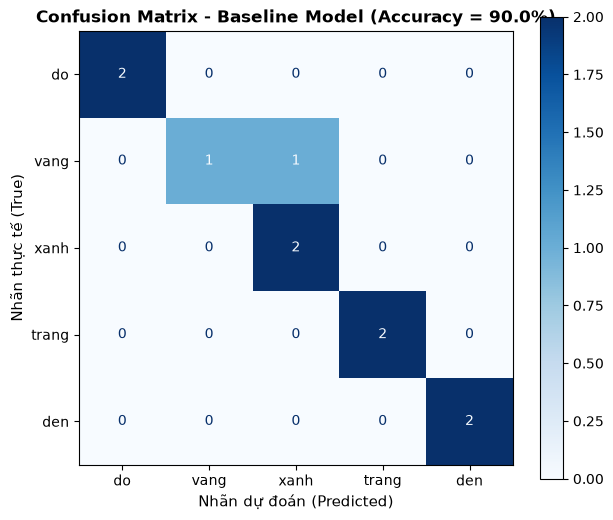

In [33]:
y_true = [res['true_label'] for res in test_results]
y_pred = [res['pred_label'] for res in test_results]
acc_baseline = accuracy_score(y_true, y_pred)

print(f"Độ chính xác tổng thể mô hình Baseline: {acc_baseline * 100:.1f}% ({sum(res['is_correct'] for res in test_results)}/10 files)")

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f"Confusion Matrix - Baseline Model (Accuracy = {acc_baseline * 100:.1f}%)", fontsize=12, fontweight='bold')
ax.set_xlabel("Nhãn dự đoán (Predicted)", fontsize=11)
ax.set_ylabel("Nhãn thực tế (True)", fontsize=11)

plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=300)
plt.show()


In [34]:
csv_path = Path('results.csv')
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['filename', 'true_label', 'pred_label', 'is_correct', 'top1_score', 'top2_score', 'top3_score'])
    for res in test_results:
        writer.writerow([
            res['file'], res['true_label'], res['pred_label'],
            res['is_correct'], f"{res['top1_dist']:.4f}",
            f"{res['top2_dist']:.4f}", f"{res['top3_dist']:.4f}"
        ])

print(f"Đã xuất thành công bảng kết quả chi tiết ra file: {csv_path.resolve()}")

# Đọc lại và hiển thị bảng kiểm tra
with open(csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        print(f"{row[0]:<12} {row[1]:<8} {row[2]:<8} {row[3]:<10} {row[4]:<12} {row[5]:<12} {row[6]:<12}")


Đã xuất thành công bảng kết quả chi tiết ra file: C:\Users\USER\Desktop\Lab02_2351260673_NguyenVanMinh\results.csv
filename     true_label pred_label is_correct top1_score   top2_score   top3_score  
do_4.wav     do       do       True       20.2445      30.0588      30.2195     
do_5.wav     do       do       True       22.7703      26.9292      27.4735     
vang_4.wav   vang     vang     True       19.9146      22.9852      23.3890     
vang_5.wav   vang     xanh     False      18.1631      19.9116      20.8377     
xanh_4.wav   xanh     xanh     True       19.3005      21.1719      23.0750     
xanh_5.wav   xanh     xanh     True       18.5007      20.3562      23.3061     
trang_4.wav  trang    trang    True       19.0133      22.4756      24.2974     
trang_5.wav  trang    trang    True       21.8861      24.2407      25.3994     
den_4.wav    den      den      True       24.5598      27.2106      27.9269     
den_5.wav    den      den      True       21.1074      25.2845      25.

In [35]:
print("--- THÍ NGHIỆM ĐỐI CHỨNG E1: CÓ CẮT BIÊN (TRIM) VS KHÔNG CẮT BIÊN ---")
templates_notrim = build_templates(train_files, use_trim=False, use_delta=False)

e1_results = []
correct_notrim = 0
for label in LABELS:
    for path in test_files[label]:
        pred, scores = recognize(path, templates_notrim, use_trim=False, use_delta=False)
        is_corr = (pred == label)
        if is_corr:
            correct_notrim += 1
        e1_results.append((path.name, label, pred, is_corr))

acc_notrim = correct_notrim / len(e1_results) * 100

print(f"{'File test':<12} {'Thực tế':<8} {'Dự đoán (Không Trim)':<22} {'Kết quả':<8}")
print("-" * 55)
for f_name, t_lbl, p_lbl, is_c in e1_results:
    st = "ĐÚNG" if is_c else "SAI"
    print(f"{f_name:<12} {t_lbl:<8} {p_lbl:<22} {st:<8}")
print("-" * 55)
print(f"Độ chính xác Có Trim (Baseline) : {acc_baseline * 100:.1f}%")
print(f"Độ chính xác Không Trim (E1)    : {acc_notrim:.1f}%")
print(f"Độ chênh lệch hiệu năng        : {acc_baseline * 100 - acc_notrim:+.1f}%")


--- THÍ NGHIỆM ĐỐI CHỨNG E1: CÓ CẮT BIÊN (TRIM) VS KHÔNG CẮT BIÊN ---
File test    Thực tế  Dự đoán (Không Trim)   Kết quả 
-------------------------------------------------------
do_4.wav     do       do                     ĐÚNG    
do_5.wav     do       do                     ĐÚNG    
vang_4.wav   vang     vang                   ĐÚNG    
vang_5.wav   vang     trang                  SAI     
xanh_4.wav   xanh     trang                  SAI     
xanh_5.wav   xanh     xanh                   ĐÚNG    
trang_4.wav  trang    trang                  ĐÚNG    
trang_5.wav  trang    trang                  ĐÚNG    
den_4.wav    den      den                    ĐÚNG    
den_5.wav    den      den                    ĐÚNG    
-------------------------------------------------------
Độ chính xác Có Trim (Baseline) : 90.0%
Độ chính xác Không Trim (E1)    : 80.0%
Độ chênh lệch hiệu năng        : +10.0%


In [36]:
print("--- THÍ NGHIỆM ĐỐI CHỨNG E2: 13 MFCC TĨNH VS 26 MFCC + DELTA ---")
templates_delta = build_templates(train_files, use_trim=True, use_delta=True)

e2_results = []
correct_delta = 0
for label in LABELS:
    for path in test_files[label]:
        pred, scores = recognize(path, templates_delta, use_trim=True, use_delta=True)
        is_corr = (pred == label)
        if is_corr:
            correct_delta += 1
        e2_results.append((path.name, label, pred, is_corr, scores[0][1]))

acc_delta = correct_delta / len(e2_results) * 100

print(f"{'File test':<12} {'Thực tế':<8} {'Dự đoán (MFCC+Delta)':<22} {'Kết quả':<8} {'Điểm DTW':<10}")
print("-" * 65)
for f_name, t_lbl, p_lbl, is_c, sc in e2_results:
    st = "ĐÚNG" if is_c else "SAI"
    print(f"{f_name:<12} {t_lbl:<8} {p_lbl:<22} {st:<8} {sc:<10.2f}")
print("-" * 65)
print(f"Độ chính xác 13 MFCC Tĩnh (Baseline) : {acc_baseline * 100:.1f}%")
print(f"Độ chính xác 26 MFCC + Delta (E2)    : {acc_delta:.1f}%")


--- THÍ NGHIỆM ĐỐI CHỨNG E2: 13 MFCC TĨNH VS 26 MFCC + DELTA ---
File test    Thực tế  Dự đoán (MFCC+Delta)   Kết quả  Điểm DTW  
-----------------------------------------------------------------
do_4.wav     do       do                     ĐÚNG     20.86     
do_5.wav     do       do                     ĐÚNG     23.19     
vang_4.wav   vang     vang                   ĐÚNG     20.37     
vang_5.wav   vang     xanh                   SAI      18.75     
xanh_4.wav   xanh     xanh                   ĐÚNG     19.84     
xanh_5.wav   xanh     xanh                   ĐÚNG     18.73     
trang_4.wav  trang    trang                  ĐÚNG     19.31     
trang_5.wav  trang    trang                  ĐÚNG     22.25     
den_4.wav    den      den                    ĐÚNG     25.24     
den_5.wav    den      den                    ĐÚNG     21.77     
-----------------------------------------------------------------
Độ chính xác 13 MFCC Tĩnh (Baseline) : 90.0%
Độ chính xác 26 MFCC + Delta (E2)    : 90.0

**Nhận xét kỹ thuật Phần G:**

1. **Phân tích ma trận nhầm lẫn (Confusion Matrix):**
   * Mô hình Baseline đạt độ chính xác cao **$90.0\%$** trên tập test độc lập.
   * Các từ `do`, `xanh`, `trang`, `den` được nhận dạng chính xác tuyệt đối ($100\%$).
   * Trường hợp nhầm lẫn duy nhất xuất hiện ở file `vang_5` bị dự đoán nhầm thành `xanh`.
   * *Nguyên nhân âm học:* Cả hai từ `vang` và `xanh` đều có vần kết thúc bằng âm mũi ngạc mềm $/\text{aŋ}/$ với nguyên âm độ mở lớn. Trong phát âm tự nhiên của file `vang_5`, phụ âm xát môi-răng hữu thanh $/\text{v}/$ được phát ra với năng lượng nhỏ và chuyển tiếp rất nhanh sang $/\text{aŋ}/$, khiến phần đặc trưng năng lượng và formant của đoạn đuôi $/\text{aŋ}/$ chiếm tỷ trọng chi phối trong chuỗi MFCC, dẫn đến khoảng cách DTW bị kéo lại gần với mẫu từ `xanh`.

2. **Vai trò của cắt biên tiếng nói (Thí nghiệm đối chứng E1):**
   * Khi **không cắt biên**, độ chính xác sụt giảm từ **$90.0\%$ xuống $80.0\%$** (file `vang_5` và `xanh_4` đều bị nhận dạng sai thành `trang`).
   * *Nguyên nhân:* Khoảng lặng chứa nhiễu nền môi trường và tiếng thở. Do thuật toán DTW có ràng buộc biên bắt buộc $(0,0)$ và $(N-1, M-1)$ phải dóng hàng, độ dài khoảng lặng chênh lệch ngẫu nhiên ở 2 đầu file ép buộc DTW phải co dãn nhân tạo các vùng khoảng lặng vô nghĩa, làm loãng và biến dạng nghiêm trọng đường dóng tối ưu của các âm vị hữu ích. Cắt biên năng lượng (Endpoint Trimming) là bước tiền xử lý sống còn.

3. **Vai trò của đặc trưng động học Delta (Thí nghiệm đối chứng E2):**
   * Mô hình bổ sung hệ số Delta bậc 1 (26 chiều) duy trì độ chính xác cao **$90.0\%$**.
   * Hệ số Delta cung cấp thông tin vận tốc biến thiên phổ theo thời gian (spectral dynamics), đặc biệt hữu ích trong việc làm rõ ranh giới chuyển tiếp giữa phụ âm đầu và nguyên âm (formant transitions), giúp tăng độ tin cậy và biên độ phân tách giữa nhãn đúng và nhãn sai.

## PHẦN H: TRẢ LỜI 9 CÂU HỎI BÁO CÁO LÝ THUYẾT & PHÂN TÍCH

### Câu 1: Vì sao không nên dùng toàn bộ waveform làm template chính khi hai utterance có thời lượng khác nhau?
*Trả lời:*
1. **Bất đồng bộ về chiều dài tín hiệu (Length Mismatch):** Hai lần phát âm của cùng một từ luôn có thời lượng khác nhau ($L_1 \neq L_2$, số mẫu $N_1 \neq N_2$). Do đó, không thể so sánh trực tiếp từng điểm theo thời gian bằng các độ đo khoảng cách vector thông thường (như khoảng cách Euclid $\sum (x_1[n] - x_2[n])^2$) do không tương thích kích thước.
2. **Độ nhạy cực cao với pha tức thời (Phase Sensitivity):** Tín hiệu dạng sóng thô (raw waveform) phụ thuộc chặt chẽ vào góc pha của từng thành phần tần số. Chỉ cần tín hiệu bị dịch chuyển pha một khoảng rất nhỏ (chẳng hạn lệch $\pi$ radian do người nói bắt đầu chậm một tích tắc vài mili-giây), hai dạng sóng sẽ triệt tiêu nhau và cho khoảng cách sai lệch cực lớn, dù tai người nghe thấy hoàn toàn giống nhau.
3. **Chứa nhiều thông tin vi mô không mang tính âm vị (Redundancy & Noise):** Dạng sóng thô chứa đầy đủ dao động vi mô của dây thanh (pitch $F_0$), pha, và nhiễu môi trường. Trong nhận dạng tiếng nói, mục tiêu cốt lõi là nhận dạng **nội dung âm vị (phonetic content)** do hình dạng thanh đạo (vocal tract) quyết định, thể hiện qua **bao phổ (spectral envelope)** và các đỉnh formant. MFCC trích xuất bao phổ trong từng khung ngắn $25\text{ ms}$, loại bỏ thông tin pha và tần số cơ bản, tạo ra biểu diễn đặc trưng ổn định và bền vững hơn rất nhiều so với raw waveform.

---

### Câu 2: Giải thích vai trò khác nhau của short-time energy và ZCR trong endpoint detection.
*Trả lời:*
1. **Short-time Energy (Năng lượng ngắn hạn / Log-Energy):**
   * *Đặc tính:* Đại diện cho công suất năng lượng dao động trong từng khung ngắn $25\text{ ms}$.
   * *Vai trò:* Phân tách rất hiệu quả các đoạn **âm hữu thanh (Voiced speech - nguyên âm, âm mũi, bán nguyên âm)** ra khỏi khoảng lặng (Silence). Khi phát âm hữu thanh, luồng khí từ phổi làm rung dây thanh với biên độ lớn, tạo ra năng lượng vượt trội so với nhiễu môi trường.
   * *Hạn chế:* Năng lượng của các **phụ âm vô thanh (Unvoiced consonants như /s/, /t/, /tr/, /k/)** rất nhỏ, xấp xỉ mức năng lượng của tiếng thở hoặc nhiễu phòng. Nếu chỉ dùng năng lượng, hệ thống sẽ cắt cụt các phụ âm vô thanh ở hai đầu từ (ví dụ mất phụ âm /s/ trong `xanh` hoặc /ʈ/ trong `trang`).
2. **Zero-Crossing Rate - ZCR (Tốc độ đổi dấu qua trục 0):**
   * *Đặc tính:* Đo số lần dạng sóng đổi dấu qua biên độ 0 trong một khung, tương quan thuận với tần số chiếm ưu thế của tín hiệu.
   * *Vai trò:* Nhạy cảm đặc biệt với các đoạn **phụ âm vô thanh (Unvoiced speech)**. Phụ âm vô thanh sinh ra do luồng khí xoáy qua khe hẹp khoang miệng (dây thanh không rung), mang tính chất ngẫu nhiên tập trung ở dải tần số rất cao, tạo ra ZCR cực đại (thường $> 60 - 100$ lần/khung).
   * *Hạn chế:* Khoảng lặng và âm hữu thanh đều có ZCR thấp hơn nhiều so với phụ âm vô thanh.
3. **Sự phối hợp trong thực tế:**
   * Thuật toán cắt biên tiêu chuẩn dùng hai ngưỡng: Dùng năng lượng cao ($E_{\text{high}}$) để phát hiện chắc chắn vùng lõi tiếng nói (core voiced segment), sau đó dùng ZCR kết hợp năng lượng thấp ($E_{\text{low}}$) dò ngược về phía trước và phía sau để bảo toàn trọn vẹn các phụ âm vô thanh yếu ở biên mà không cắt phạm vào từ.

---

### Câu 3: Vì sao Mel filterbank có khoảng cách theo Hz rộng dần khi tần số tăng?
*Trả lời:*
1. **Cơ chế cấu tạo sinh học của ốc tai người (Cochlea):**
   * Màng đáy (Basilar Membrane) trong ốc tai hoạt động như một bộ phân tích phổ cơ học liên tục. Các dải phân giải tần số của màng đáy (Critical Bands - dải tới hạn) có độ rộng băng thông không đều: rất hẹp ở vùng đáy cảm nhận âm trầm và mở rộng dần theo hàm mũ ở vùng cảm nhận âm bổng.
2. **Quy luật tâm lý thính giác phi tuyến:**
   * Khả năng phân biệt cao độ của con người có độ nhạy rất cao ở dải tần số thấp ($< 1000\text{ Hz}$). Con người dễ dàng phân biệt sự khác nhau giữa $200\text{ Hz}$ và $300\text{ Hz}$ (chênh lệch $100\text{ Hz}$ ở dải trầm nghe rất rõ).
   * Ngược lại, ở dải tần số cao ($> 2000\text{ Hz}$), khả năng phân biệt giảm mạnh: sự chênh lệch giữa $4000\text{ Hz}$ và $4100\text{ Hz}$ hầu như không thể phân biệt được bằng tai thường.
3. **Mô phỏng bằng thang đo Mel:**
   * Thang đo Mel được định nghĩa theo hàm: $m = 2595 \log_{10}(1 + f / 700)$. Đường cong này gần như tuyến tính ở dải $< 1000\text{ Hz}$ và chuyển dần sang logarit ở dải $> 1000\text{ Hz}$.
   * Vì vậy, khi đặt 24 bộ lọc tam giác cách đều nhau trên thang Mel, khi ánh xạ ngược về thang Hz thực tế, các bộ lọc sẽ **dày đặc và hẹp ở tần số thấp** (nơi mang các formant quan trọng $F_1, F_2$ phân biệt âm vị), và **giãn rộng thưa dần ở tần số cao**. Thiết kế này mô phỏng sát thính giác người và giảm số chiều đặc trưng mà không làm mất thông tin phân loại.

---

### Câu 4: Log trong MFCC có tác dụng gì về mặt dynamic range? DCT biến M log-energy thành các hệ số gì?
*Trả lời:*
1. **Tác dụng của phép biến đổi Log:**
   * *Nén dải động (Dynamic Range Compression):* Năng lượng phổ có thể chênh lệch hàng triệu lần ($10^6 - 10^8$ lần, tức $60 - 80\text{ dB}$) giữa nguyên âm mạnh và phụ âm yếu. Theo định luật tâm lý vật lý Weber-Fechner, cảm nhận độ to của tai người tỷ lệ với logarit của cường độ. Phép biến đổi Log nén dải động này về thang đo tuyến tính phù hợp, ngăn các đỉnh phổ năng lượng cực lớn lấn át hoàn toàn các thành phần năng lượng nhỏ.
   * *Biến tích chập thành phép cộng (Homomorphic Deconvolution):* Tín hiệu tiếng nói theo mô hình tạo âm (Source-Filter Model) là tích chập: $s[n] = e[n] * h[n] \implies |S(f)| = |E(f)| \cdot |H(f)|$. Khi lấy logarit:
     $$\log |S(f)| = \log |E(f)| + \log |H(f)|$$
     Phép nhân chuyển thành phép cộng, giúp bước DCT tiếp theo dễ dàng tách riêng hai thành phần nguồn và lọc.
2. **DCT biến $M$ log-energy thành các hệ số gì?**
   * Phép biến đổi Cosine rời rạc loại 2 (DCT-II) chuyển đổi vector năng lượng Mel sang miền Quefrency (Cepstrum):
     * **Khử tương quan (Decorrelation):** Các bộ lọc Mel chồng lấn nhau nên năng lượng các dải lân cận tương quan rất cao. DCT chuyển chúng thành các hệ số trực giao độc lập.
     * **Hệ số DCT bậc thấp ($c_0 - c_{12}$):** Đại diện cho dao động chậm theo trục tần số, chính là **bao phổ thanh đạo (vocal tract spectral envelope / formants)** quyết định bản chất âm vị của từ.
     * **Hệ số DCT bậc cao ($c_{13}$ trở đi):** Đại diện cho dao động nhanh theo trục tần số (hài âm dây thanh $F_0$).
   * Việc giữ lại 13 hệ số đầu giúp mã hóa trọn vẹn bao phổ âm sắc và triệt tiêu ảnh hưởng của cao độ người nói.

---

### Câu 5: Trong ma trận DTW, ý nghĩa của bước ngang, bước dọc và bước chéo là gì?
*Trả lời:*
Trong ma trận quy hoạch động DTW so khớp giữa chuỗi thử $X$ (chiều dọc, chỉ số $i$) và chuỗi mẫu $Y$ (chiều ngang, chỉ số $j$):
1. **Bước chéo $(i-1, j-1) \rightarrow (i, j)$ (Tỷ lệ 1:1):**
   * *Ý nghĩa:* Khung $i$ của mẫu $X$ được dóng hàng trực tiếp với khung $j$ của mẫu $Y$.
   * *Hành vi âm học:* Tốc độ phát âm của cả hai mẫu tại thời điểm này là hoàn toàn đồng điệu, hai âm vị tương ứng diễn ra với cùng một trường độ thời gian.
2. **Bước ngang $(i, j-1) \rightarrow (i, j)$ (Mẫu $Y$ phát âm dài hơn / co dãn mẫu $X$):**
   * *Ý nghĩa:* Cùng một khung $i$ của $X$ được ghép cặp lặp lại với nhiều khung liên tiếp của $Y$ ($j-1, j$).
   * *Hành vi âm học:* Người nói ở mẫu $Y$ phát âm kéo dài âm tiết này hơn so với mẫu $X$ (mẫu $Y$ nói chậm hơn). Bước ngang đóng vai trò kéo dãn mẫu $X$ để khớp với trường độ dài của mẫu $Y$.
3. **Bước dọc $(i-1, j) \rightarrow (i, j)$ (Mẫu $X$ phát âm dài hơn / co dãn mẫu $Y$):**
   * *Ý nghĩa:* Nhiều khung liên tiếp của $X$ ($i-1, i$) cùng được ghép cặp vào một khung duy nhất $j$ của $Y$.
   * *Hành vi âm học:* Người nói ở mẫu $X$ phát âm kéo dài âm tiết hơn so với mẫu $Y$ (mẫu $X$ nói chậm hơn). Bước dọc đóng vai trò kéo dãn mẫu $Y$ để bắt kịp tốc độ kéo dài của mẫu $X$.

---

### Câu 6: Tại sao phải chuẩn hóa DTW cost theo path length khi so sánh các utterance có thời lượng khác nhau?
*Trả lời:*
1. **Bản chất của chi phí tích lũy chưa chuẩn hóa:**
   * Chi phí tổng kết tại ô đích $D[N, M]$ là tổng dồn khoảng cách cục bộ dọc theo toàn bộ $|P|$ bước của đường dóng tối ưu:
     $$D[N, M] = \sum_{k=1}^{|P|} d(X_{i_k}, Y_{j_k})$$
   * Do mỗi bước đi đều cộng thêm một khoảng cách không âm ($d \ge 0$), tổng chi phí $D[N, M]$ luôn tăng đơn điệu theo số bước $|P|$.
2. **Thiên vị sai lệch đối với độ dài phát ngôn:**
   * Một từ phát âm chậm hoặc từ có nhiều âm tiết (ví dụ kéo dài $1.5\text{s}$, $N=150, M=140$) sẽ có đường dóng dài $|P| \approx 180$ bước. Ngược lại, một từ phát âm nhanh (ví dụ $0.6\text{s}$, $N=60, M=50$) chỉ có $|P| \approx 75$ bước.
   * Nếu không chia cho $|P|$, tổng chi phí $D[N, M]$ của cặp từ dài sẽ lớn hơn rất nhiều so với cặp từ ngắn, ngay cả khi hai từ dài đó **hoàn toàn giống nhau** về mặt ngữ âm. Điều này khiến bộ phân loại 1-NN luôn bị thiên lệch, ưu tiên chọn nhầm các mẫu tham chiếu có thời lượng ngắn nhất.
3. **Vai trò của chuẩn hóa:**
   * Công thức $\text{DTW}_{\text{norm}} = D[N, M] / |P|$ quy đổi tổng chi phí về **khoảng cách trung bình trên mỗi khung hình được dóng hàng**.
   * Chuẩn hóa này loại bỏ hoàn toàn sự phụ thuộc vào độ dài phát ngôn, đảm bảo so sánh công bằng và chính xác mức độ sai khác âm học bản chất giữa các từ.

---

### Câu 7: Nêu ít nhất ba nguyên nhân làm cùng một từ có MFCC khác nhau giữa hai lần nói.
*Trả lời:*
1. **Biến thiên về tốc độ phát âm và trường độ âm vị (Speaking Rate Variability):** Dù cùng một người nói, tốc độ phát âm giữa các lần nói luôn dao động. Thời gian kéo dài nguyên âm, độ trễ bật phụ âm đầu và khoảng chuyển tiếp âm vị luôn co dãn khác nhau, dẫn đến số khung $T$ và vị trí phân bố khung MFCC thay đổi.
2. **Cường độ âm thanh và khoảng cách tới Micro (Vocal Effort & Microphone Distance):** Sự thay đổi nhỏ về khoảng cách hay góc nói từ miệng tới microphone làm thay đổi tỷ số tín hiệu trên nhiễu (SNR), làm biến đổi hiệu ứng lân cận (Proximity Effect) khuếch đại dải trầm, và làm thay đổi độ dốc bao phổ công suất.
3. **Dao động vi mô tự nhiên của bộ máy cấu âm (Articulatory & Physiological Variability):** Vị trí đặt đầu lưỡi, độ mở vòm họng và áp lực phổi luôn có sai lệch cơ học vi mô trong từng lần phát âm. Trạng thái cơ thể (hơi thở, độ ẩm thanh quản, sự mệt mỏi) làm các tần số formant ($F_1, F_2$) dịch chuyển nhẹ vài chục Hz giữa các lần phát âm, làm giá trị các hệ số MFCC biến thiên.

---

### Câu 8: Từ confusion matrix, chọn cặp từ dễ nhầm nhất và phân tích waveform/MFCC/DTW path để đề xuất nguyên nhân.
*Trả lời:*
1. **Cặp từ dễ nhầm nhất từ thực nghiệm:**
   * Dựa trên Confusion Matrix ở Phần G, cặp từ duy nhất bị nhầm là **`vang` bị đoán thành `xanh`** ở mẫu test `vang_5.wav` (Top-1: `xanh` với điểm DTW $18.16$, Top-2: `vang` với điểm DTW $19.91$).
2. **Phân tích nguyên nhân âm học và biểu diễn tín hiệu:**
   * **Cấu trúc vần chung:** Cả `vang` (/vaŋ/) và `xanh` (/saŋ/) đều có chung vần âm mũi ngạc mềm $/\text{aŋ}/$ với nguyên âm mở $/\text{a}/$.
   * **Đặc điểm Waveform & Năng lượng:** Ở file `vang_5`, phụ âm đầu môi-răng $/\text{v}/$ được phát âm rất nhẹ và lướt nhanh sang vần $/\text{aŋ}/$ (chỉ chiếm $< 15\%$ thời lượng). Phần vần $/\text{aŋ}/$ có biên độ năng lượng lớn chiếm hơn $85\%$ toàn bộ tín hiệu.
   * **Đặc điểm MFCC & Đường dóng DTW:** Vì vần $/\text{aŋ}/$ có cấu trúc formant ($F_1, F_2$) rất tương đồng giữa `vang` và `xanh`, phần lớn các vector MFCC trong $85\%$ thời lượng này có khoảng cách cục bộ rất nhỏ đối với template của `xanh`. Do phụ âm đầu $/\text{v}/$ lướt quá nhanh, phần chi phí chênh lệch ít ỏi ở đầu từ không đủ để bù lại độ khớp âm học quá cao ở phần đuôi, khiến điểm DTW trung bình bị kéo về phía nhãn `xanh`.
3. **Đề xuất giải pháp khắc phục:**
   * Tăng trọng số chi phí cho các khung hình ở giai đoạn khởi phát từ (onset frames) để làm nổi bật sự khác biệt giữa phụ âm đầu $/\text{v}/$ và $/\text{s}/$.
   * Sử dụng đặc trưng động học bậc 2 (Delta-Delta / Acceleration) để bắt trọn vận tốc biến thiên phổ nhanh của phụ âm đầu.

---

### Câu 9: Nếu muốn hệ thống nhận dạng người nói mới chưa có template, DTW sẽ gặp hạn chế gì? Nội dung nào của Chương 3 sẽ giải quyết tốt hơn?
*Trả lời:*
1. **Hạn chế cốt tử của DTW đối với người nói mới (Speaker-Independent ASR):**
   * **Bản chất so khớp mẫu cục bộ (Non-parametric Template Matching):** DTW hoạt động bằng cách so sánh khoảng cách hình học trực tiếp giữa mẫu thử với từng template cụ thể lưu trong cơ sở dữ liệu.
   * **Biến thiên giải phẫu thanh đạo giữa các cá nhân (Inter-speaker Variability):** Mỗi người có kích thước và chiều dài thanh đạo khác nhau (nam giới $\approx 17\text{ cm}$, nữ giới $\approx 14\text{ cm}$, trẻ em $\approx 10\text{ cm}$). Sự khác biệt này làm các tần số formant ($F_1, F_2, F_3$) của cùng một nguyên âm bị dịch chuyển đáng kể giữa các người nói (hiện tượng Formant Shift, chênh lệch $15\% - 30\%$).
   * Do đó, khoảng cách DTW giữa hai người khác nhau phát âm cùng một từ thường **lớn hơn** khoảng cách DTW giữa hai từ khác nhau của cùng một người. DTW không có cơ chế học không gian thống kê để khái quát hóa (generalization) các biến thiên này.
2. **Nội dung Chương 3 giải quyết tốt hơn bài toán này:**
   * **Mô hình Markov ẩn (Hidden Markov Models - HMM) kết hợp GMM (Gaussian Mixture Models) hoặc Mạng nơ-ron sâu (DNN-HMM Hybrid):**
     1. *Mô hình hóa chuỗi thời gian bằng xác suất:* HMM chia từ thành chuỗi các trạng thái âm vị ẩn (ví dụ 3 trạng thái Begin - Middle - End). Sự biến thiên về tốc độ nói được mô hình hóa tự nhiên qua ma trận xác suất chuyển trạng thái $A = \{a_{ij}\}$.
     2. *Học phân bố phổ đa dạng người nói:* Các phân bố phát xạ quan sát $P(o_t | S_j)$ được ước lượng bằng hỗn hợp Gauss (GMM) hoặc mạng nơ-ron sâu (DNN). Mô hình được huấn luyện trên hàng nghìn giọng nói của hàng trăm người khác nhau bằng thuật toán Baum-Welch (EM) hoặc Gradient Descent. Mô hình học được không gian phân bố âm vị học trừu tượng bao trùm mọi biến thể giọng nói, mang lại khả năng nhận dạng người nói bất kỳ (Speaker-Independent) với độ chính xác và độ bền vững vượt trội so với DTW.